# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [8]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [70]:
df_original = pd.read_csv("data/nndb_flat.csv")
df_original.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [71]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


### Mira a ver la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

USRDA: misma vitamina/mineral expresada como % de la ingesta diaria recomendada.
Esas columnas presentan correlaciones perfectas con la variable de la la que derivan. Existe mucha redundancia.
Lo recomendable sería eliminar esas variables.

In [72]:
df_original.corr(numeric_only=True)

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
ID,1.000000,0.126126,0.075538,-0.011996,0.177297,0.082710,0.008252,-0.031211,-0.060463,0.016512,...,-0.051166,0.010387,-0.024343,0.011311,-0.050720,-0.003765,-0.001867,0.045925,0.011775,0.009195
Energy_kcal,0.126126,1.000000,0.110302,0.806795,0.487096,0.313151,0.197338,0.026329,0.121872,-0.012292,...,0.145936,0.174991,0.155830,0.187439,0.123571,0.099513,0.255880,0.195181,0.056673,0.112766
Protein_g,0.075538,0.110302,1.000000,0.054715,-0.301974,-0.266170,-0.072777,0.026483,0.228485,0.245423,...,0.008939,0.376939,0.202480,0.098360,0.046888,0.158900,0.218611,0.444608,0.378369,0.416315
Fat_g,-0.011996,0.806795,0.054715,1.000000,-0.054116,-0.001962,-0.028842,0.024379,-0.046950,-0.020786,...,-0.058049,-0.022671,-0.036286,-0.005785,0.015039,0.042765,0.070781,0.066086,0.037559,0.028264
Carb_g,0.177297,0.487096,-0.301974,-0.054116,1.000000,0.615344,0.458192,0.001871,0.195571,-0.094636,...,0.325170,0.173285,0.232408,0.281809,0.189106,0.062106,0.287207,0.073180,-0.114600,-0.012187
Sugar_g,0.082710,0.313151,-0.266170,-0.001962,0.615344,1.000000,0.115916,0.010143,0.088767,-0.050450,...,0.161257,0.034378,0.125225,0.097751,0.129540,-0.005837,0.041308,-0.049784,-0.123708,-0.021991
Fiber_g,0.008252,0.197338,-0.072777,-0.028842,0.458192,0.115916,1.000000,0.005910,0.242804,-0.052045,...,0.249075,0.135257,0.157703,0.205211,0.232286,0.185044,0.542038,0.158422,-0.035897,0.085154
VitA_mcg,-0.031211,0.026329,0.026483,0.024379,0.001871,0.010143,0.005910,1.000000,0.136605,0.581004,...,0.108517,0.151679,0.325709,0.052921,0.034822,0.569945,0.024572,0.055814,0.048043,0.070541
VitB6_mg,-0.060463,0.121872,0.228485,-0.046950,0.195571,0.088767,0.242804,0.136605,1.000000,0.264325,...,0.550087,0.714143,0.581678,0.417011,0.177268,0.116326,0.293169,0.213395,0.109004,0.447143
VitB12_mcg,0.016512,-0.012292,0.245423,-0.020786,-0.094636,-0.050450,-0.052045,0.581004,0.264325,1.000000,...,0.158483,0.279033,0.436182,0.099601,0.011715,0.570642,0.004124,0.148774,0.215308,0.298136


<Axes: >

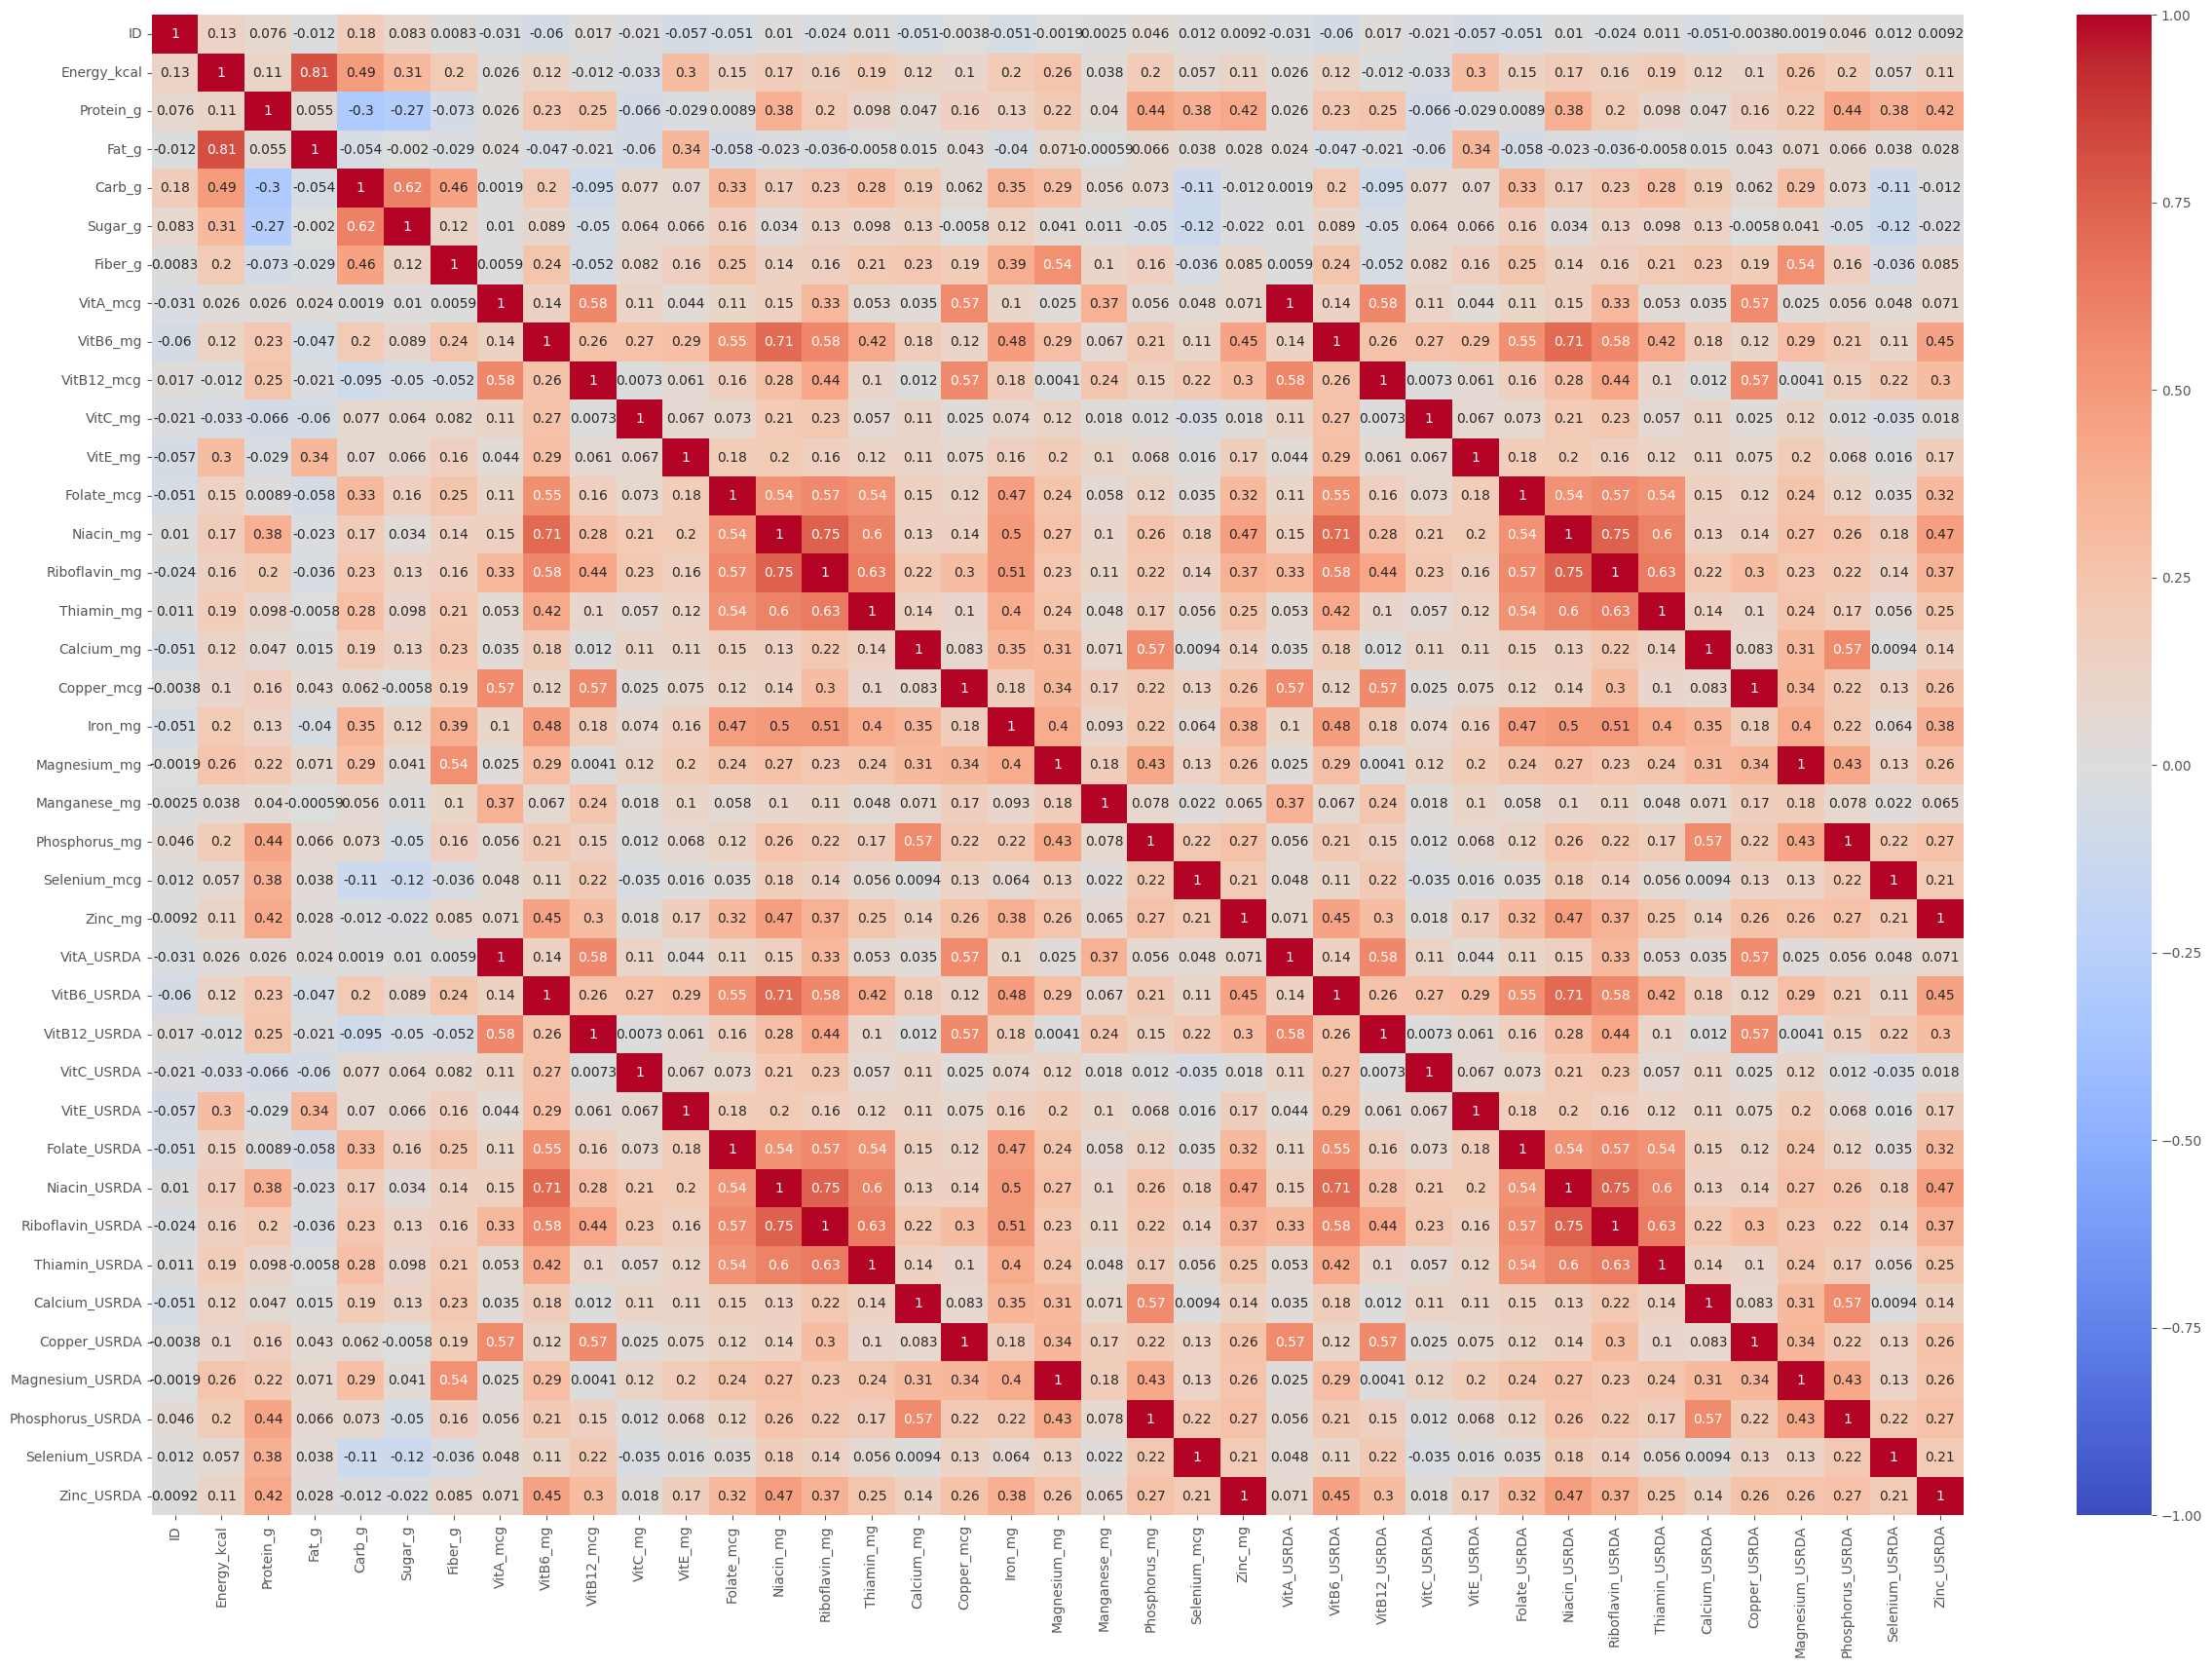

In [73]:
plt.figure(figsize=(30, 20))
sns.heatmap(df_original.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1)

### Variables no numéricas
Elimina las variables de texto del dataset

In [74]:
df = df_original.copy()
df = df.drop(columns=["ID", "FoodGroup", "ShortDescrip", "Descrip", "CommonName", "MfgName", "ScientificName"])
df.head()

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,0.0,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,0.0,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,0.0,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,0.0,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,0.0,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Energy_kcal       8618 non-null   float64
 1   Protein_g         8618 non-null   float64
 2   Fat_g             8618 non-null   float64
 3   Carb_g            8618 non-null   float64
 4   Sugar_g           8618 non-null   float64
 5   Fiber_g           8618 non-null   float64
 6   VitA_mcg          8618 non-null   float64
 7   VitB6_mg          8618 non-null   float64
 8   VitB12_mcg        8618 non-null   float64
 9   VitC_mg           8618 non-null   float64
 10  VitE_mg           8618 non-null   float64
 11  Folate_mcg        8618 non-null   float64
 12  Niacin_mg         8618 non-null   float64
 13  Riboflavin_mg     8618 non-null   float64
 14  Thiamin_mg        8618 non-null   float64
 15  Calcium_mg        8618 non-null   float64
 16  Copper_mcg        8618 non-null   float64


### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

In [76]:
df_log = df.copy()

In [77]:
df_log = np.log1p(df_log)
df_log

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,6.576470,0.615186,4.408060,0.058269,0.058269,0.0,6.529419,0.002996,0.157004,0.0,...,0.007472,0.002622,0.025818,0.004158,0.019803,0.000000,0.004751,0.033711,0.018019,0.008149
1,6.576470,0.615186,4.408060,0.058269,0.058269,0.0,6.529419,0.002996,0.122218,0.0,...,0.007472,0.002622,0.025818,0.004158,0.019803,0.000018,0.004751,0.032329,0.018019,0.004535
2,6.776507,0.246860,4.609959,0.000000,0.000000,0.0,6.734592,0.001000,0.009950,0.0,...,0.000000,0.000187,0.003839,0.000833,0.003328,0.000001,0.000000,0.004277,0.000000,0.000909
3,5.869297,3.109061,3.392493,1.205971,0.405465,0.0,5.293305,0.153579,0.797507,0.0,...,0.086178,0.061565,0.257619,0.023879,0.364643,0.000044,0.053315,0.440097,0.233994,0.216577
4,5.918894,3.188004,3.423611,1.332366,0.412110,0.0,5.680173,0.062975,0.815365,0.0,...,0.048790,0.007348,0.239017,0.011599,0.445754,0.000027,0.055570,0.497306,0.233994,0.212175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,5.723585,2.970414,3.261935,0.000000,0.000000,0.0,3.871201,0.343590,2.564949,0.0,...,0.036814,0.187516,0.136412,0.016529,0.053541,0.000111,0.133531,0.309583,0.847817,0.095310
8614,4.718499,3.069912,0.609766,1.857859,0.000000,0.0,1.098612,0.106160,1.147402,0.0,...,0.048790,0.065085,0.018293,0.009950,0.008299,0.000037,0.084429,0.475346,0.332569,0.131825
8615,5.598422,0.000000,0.000000,4.305955,4.306764,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,0.006231,0.045120,0.102857,0.010775,0.000022,0.023530,0.011364,0.012647,0.017125
8616,4.510860,2.839078,0.875469,1.098612,0.000000,0.0,3.433987,0.122218,0.405465,0.0,...,0.014889,0.083881,0.088293,0.008299,0.008299,0.000444,0.467023,0.328275,0.404252,0.087011


### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [78]:
st = StandardScaler()
df_std = pd.DataFrame(st.fit_transform(df_log), columns=df_log.columns)
df_std

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1.540414,-1.379699,2.222526,-1.279339,-0.751381,-0.817818,2.363105,-0.811366,-0.453749,-0.63502,...,-0.370982,-0.908747,-0.657634,-0.662004,-0.308239,-0.312588,-0.657347,-0.935289,-0.728859,-0.767043
1,1.540414,-1.379699,2.222526,-1.279339,-0.751381,-0.817818,2.363105,-0.811366,-0.506894,-0.63502,...,-0.370982,-0.908747,-0.657634,-0.662004,-0.308239,-0.283509,-0.657347,-0.943791,-0.728859,-0.787228
2,1.745661,-1.728220,2.393490,-1.315522,-0.796963,-0.817818,2.463472,-0.819681,-0.678411,-0.63502,...,-0.406514,-0.921739,-0.777857,-0.678859,-0.464122,-0.310770,-0.705592,-1.116339,-0.811468,-0.807485
3,0.814824,0.980084,1.362565,-0.566664,-0.479778,-0.817818,1.758419,-0.184016,0.524785,-0.63502,...,0.003292,-0.594143,0.610310,-0.562034,2.954611,-0.239893,-0.164140,1.564362,0.261316,0.397249
4,0.865713,1.054782,1.388915,-0.488178,-0.474580,-0.817818,1.947668,-0.561485,0.552068,-0.63502,...,-0.174499,-0.883521,0.508555,-0.624284,3.722071,-0.268970,-0.141241,1.916255,0.261316,0.372659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,0.665317,0.848892,1.252011,-1.315522,-0.796963,-0.817818,1.062751,0.607592,3.225009,-0.63502,...,-0.231450,0.078102,-0.052689,-0.599292,0.010988,-0.130857,0.650513,0.761584,3.075496,-0.280153
8614,-0.365945,0.943039,-0.993791,-0.161868,-0.796963,-0.817818,-0.293552,-0.381569,1.059341,-0.63502,...,-0.174499,-0.575356,-0.698792,-0.632642,-0.417087,-0.252614,0.151841,1.781183,0.713250,-0.076176
8615,0.536895,-1.961806,-1.510128,1.358297,2.572113,-0.817818,-0.830974,-0.823845,-0.693613,-0.63502,...,-0.406514,-0.889485,-0.552049,-0.161682,-0.393657,-0.276240,-0.466624,-1.072746,-0.753486,-0.716899
8616,-0.578992,0.724618,-0.768799,-0.633329,-0.796963,-0.817818,0.848873,-0.314672,-0.074160,-0.63502,...,-0.335714,-0.475034,-0.315899,-0.641013,-0.417087,0.414215,4.037356,0.876558,1.041896,-0.326510


### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [79]:
pca = PCA(n_components=None)
pca.fit(df_std)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [80]:
# Se han creado 38 Principal Components (PC), uno por cada variable
print(pca.explained_variance_ratio_)


[3.16157279e-01 1.37711624e-01 8.00374027e-02 6.33485108e-02
 5.57447494e-02 4.33630043e-02 4.16104351e-02 3.05809545e-02
 2.45851759e-02 2.37352999e-02 2.10159932e-02 1.87453609e-02
 1.53410769e-02 1.46628266e-02 1.34941763e-02 1.27655515e-02
 1.18982602e-02 1.02278046e-02 9.04838029e-03 7.78111087e-03
 7.05986953e-03 6.60738300e-03 5.89590634e-03 5.26748923e-03
 4.35135686e-03 4.01099659e-03 3.79923344e-03 2.48051795e-03
 1.99698744e-03 1.79977764e-03 1.75253415e-03 1.57895392e-03
 8.41345856e-04 5.44867836e-04 1.05451346e-04 3.71990876e-05
 1.04905286e-05 4.66256925e-06]


In [81]:
varianzas = np.array([
    3.23900635e-01, 1.40471532e-01, 7.25563112e-02, 6.50411644e-02,
    5.39970343e-02, 4.22975292e-02, 3.71163288e-02, 3.01583963e-02,
    2.35272765e-02, 2.23978264e-02, 2.03350106e-02, 1.83672796e-02,
    1.57812470e-02, 1.36869983e-02, 1.29707652e-02, 1.23960598e-02,
    1.11351146e-02, 9.90473082e-03, 8.37719258e-03, 8.04105472e-03,
    7.14942198e-03, 6.92683968e-03, 6.33993228e-03, 6.17098791e-03,
    5.22799562e-03, 4.62789216e-03, 4.24654373e-03, 4.01793898e-03,
    3.18172224e-03, 2.85942737e-03, 2.45541609e-03, 2.15434993e-03,
    1.19731697e-03, 7.79134806e-04, 1.31034138e-04, 5.27979142e-05,
    1.54275874e-05, 6.33370126e-06
])

df_var = pd.DataFrame(
    data=varianzas,
    columns=['Explicacion_varianzas'],
    index=[f'PC{i+1}' for i in range(len(varianzas))]
)

df_var

,Explicacion_varianzas
PC1,0.323901
PC2,0.140472
PC3,0.072556
PC4,0.065041
PC5,0.053997
PC6,0.042298
PC7,0.037116
PC8,0.030158
PC9,0.023527
PC10,0.022398


### Aportación de cada PC
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

Con 7 ().

Lo que hace cumsum() es sumar progresivamente los valores, justo lo que necesitamos para ver la información acumulada de los componentes

In [82]:
df_var['Varianza_acumulada'] = df_var['Explicacion_varianzas'].cumsum()

print(df_var)

      Explicacion_varianzas  Varianza_acumulada
PC1                0.323901            0.323901
PC2                0.140472            0.464372
PC3                0.072556            0.536928
PC4                0.065041            0.601970
PC5                0.053997            0.655967
PC6                0.042298            0.698264
PC7                0.037116            0.735381
PC8                0.030158            0.765539
PC9                0.023527            0.789066
PC10               0.022398            0.811464
PC11               0.020335            0.831799
PC12               0.018367            0.850166
PC13               0.015781            0.865948
PC14               0.013687            0.879635
PC15               0.012971            0.892605
PC16               0.012396            0.905001
PC17               0.011135            0.916137
PC18               0.009905            0.926041
PC19               0.008377            0.934418
PC20               0.008041            0

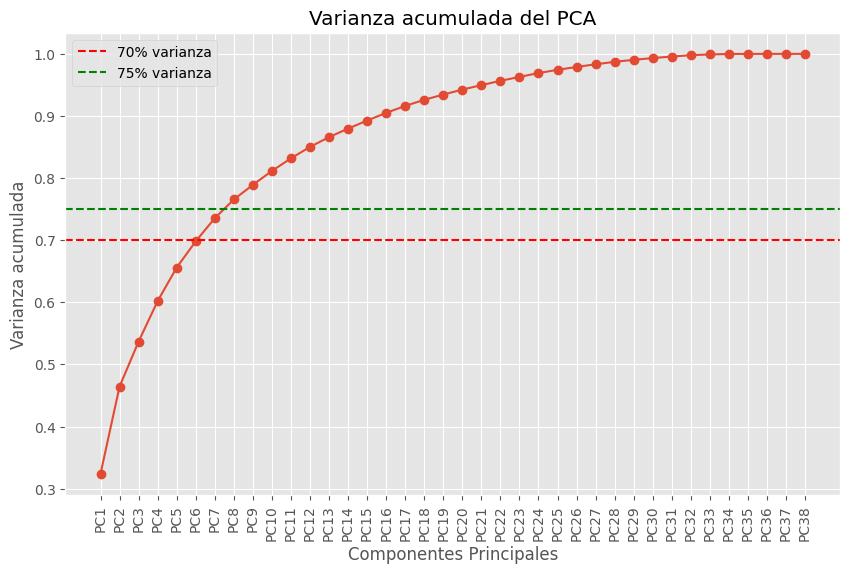

In [83]:
plt.figure(figsize=(10,6))
plt.plot(df_var.index, df_var['Varianza_acumulada'], marker='o', linestyle='-')
plt.xticks(rotation=90)
plt.xlabel('Componentes Principales')
plt.ylabel('Varianza acumulada')
plt.title('Varianza acumulada del PCA')
plt.grid(True)
plt.axhline(y=0.70, color='r', linestyle='--', label='70% varianza')
plt.axhline(y=0.75, color='g', linestyle='--', label='75% varianza')
plt.legend()
plt.show()



In [84]:
n_70 = np.argmax(df_var['Varianza_acumulada'] >= 0.70) + 1
n_75 = np.argmax(df_var['Varianza_acumulada'] >= 0.75) + 1
print(f"Para cubrir el 70% de varianza: {n_70} PCAs")
print(f"Para cubrir el 75% de varianza: {n_75} PCAs")

Para cubrir el 70% de varianza: 7 PCAs
Para cubrir el 75% de varianza: 8 PCAs


## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PCAs escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [85]:
pca_final = PCA(n_components=7)

pca_final.fit(df_std)

,n_components,7
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [86]:
pca_final.explained_variance_ratio_

array([0.31615728, 0.13771162, 0.0800374 , 0.06334851, 0.05574475,
       0.043363  , 0.04161044])

In [88]:
varianzas = np.array([
    0.32390063, 
    0.14047153, 
    0.07255631, 
    0.06504116, 
    0.05399703,
    0.04229753, 
    0.03711633
    ])

df_var_final = pd.DataFrame(
    data=varianzas,
    columns=['Explicacion_varianzas'],
    index=[f'PC{i+1}' for i in range(len(varianzas))]
)

df_var_final

,Explicacion_varianzas
PC1,0.323901
PC2,0.140472
PC3,0.072556
PC4,0.065041
PC5,0.053997
PC6,0.042298
PC7,0.037116


In [90]:
array_final_pca = pca_final.transform(df_std)
array_final_pca

array([[-2.82346763, -0.21723553, -0.55421178, ...,  4.15019034,
        -0.31879894,  1.90102957],
       [-2.80693955, -0.15801341, -0.52186892, ...,  4.14006813,
        -0.25693499,  1.90712438],
       [-3.73457302, -0.15523959, -1.23749091, ...,  5.06212825,
         0.55774822,  1.75694196],
       ...,
       [-3.56956422,  1.56608882, -0.16293237, ..., -0.16261907,
         0.80098955,  1.08859341],
       [ 1.36041808, -0.32787152,  2.45745143, ...,  1.62477893,
        -0.18799805, -2.19861049],
       [-0.00545541, -1.32758045,  0.41426972, ..., -0.52003108,
        -0.83349401,  0.5206264 ]], shape=(8618, 7))

In [91]:
array_final_pca.shape[1]

7

In [92]:
df_pca_final = pd.DataFrame(
    array_final_pca, 
    columns=[f'PC{i+1}' for i in range(array_final_pca.shape[1])]
)

df_pca_final

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-2.823468,-0.217236,-0.554212,1.156498,4.150190,-0.318799,1.901030
1,-2.806940,-0.158013,-0.521869,1.154281,4.140068,-0.256935,1.907124
2,-3.734573,-0.155240,-1.237491,0.746765,5.062128,0.557748,1.756942
3,1.710787,-1.028797,1.160348,1.804940,0.765526,-2.923539,2.974141
4,1.464149,-0.870991,1.554679,2.279470,0.967722,-3.293454,3.664296
...,...,...,...,...,...,...,...
8613,3.183835,-3.664996,-0.191398,2.150671,2.144942,-1.424308,0.205861
8614,-0.042803,-2.403307,1.012406,1.265350,-1.089670,-0.637642,-0.207899
8615,-3.569564,1.566089,-0.162932,-1.557535,-0.162619,0.800990,1.088593
8616,1.360418,-0.327872,2.457451,2.498491,1.624779,-0.187998,-2.198610


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [102]:
df_pc1 = df_pca_final["PC1"].sort_values(ascending=False)
df_pc2 = df_pca_final["PC2"].sort_values(ascending=False)
df_pc3 = df_pca_final["PC3"].sort_values(ascending=False)
df_pc4 = df_pca_final["PC4"].sort_values(ascending=False)
df_pc5 = df_pca_final["PC5"].sort_values(ascending=False)
df_pc6 = df_pca_final["PC6"].sort_values(ascending=False)
df_pc7 = df_pca_final["PC7"].sort_values(ascending=False)

df_foodgroups = pd.concat([df_original["FoodGroup"], df_original["ShortDescrip"], df_pc1, df_pc2, df_pc3, df_pc4, df_pc5, df_pc6, df_pc7], axis=1)
df_foodgroups.head()

,FoodGroup,ShortDescrip,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,Dairy and Egg Products,"BUTTER,WITH SALT",-2.823468,-0.217236,-0.554212,1.156498,4.150190,-0.318799,1.901030
1,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT",-2.806940,-0.158013,-0.521869,1.154281,4.140068,-0.256935,1.907124
2,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS",-3.734573,-0.155240,-1.237491,0.746765,5.062128,0.557748,1.756942
3,Dairy and Egg Products,"CHEESE,BLUE",1.710787,-1.028797,1.160348,1.804940,0.765526,-2.923539,2.974141
4,Dairy and Egg Products,"CHEESE,BRICK",1.464149,-0.870991,1.554679,2.279470,0.967722,-3.293454,3.664296


In [101]:
df_original["FoodGroup"].value_counts()

FoodGroup
Beef Products                          946
Vegetables and Vegetable Products      828
Baked Products                         797
Soups, Sauces, and Gravies             452
Lamb, Veal, and Game Products          438
Poultry Products                       390
Legumes and Legume Products            389
Fast Foods                             371
Breakfast Cereals                      363
Baby Foods                             362
Sweets                                 347
Fruits and Fruit Juices                346
Pork Products                          343
Beverages                              315
Finfish and Shellfish Products         267
Dairy and Egg Products                 264
Sausages and Luncheon Meats            244
Fats and Oils                          219
Cereal Grains and Pasta                183
Snacks                                 171
American Indian/Alaska Native Foods    165
Nut and Seed Products                  133
Meals, Entrees, and Side Dishes        113
R

In [ ]:
top_groups = {}

for i in range(1, 8):
    pc = f'PC{i}'
    top_indices = df_pca_final[pc].nlargest(3).index 
    top_groups[pc] = df_original.loc[top_indices, "FoodGroup"].values  


df_top_groups = pd.DataFrame(top_groups)
df_top_groups

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,Breakfast Cereals,Vegetables and Vegetable Products,Sweets,"Lamb, Veal, and Game Products",Fats and Oils,"Lamb, Veal, and Game Products","Lamb, Veal, and Game Products"
1,Breakfast Cereals,Vegetables and Vegetable Products,Nut and Seed Products,"Lamb, Veal, and Game Products",Fats and Oils,"Lamb, Veal, and Game Products","Lamb, Veal, and Game Products"
2,Breakfast Cereals,Breakfast Cereals,Spices and Herbs,Beef Products,Fats and Oils,"Lamb, Veal, and Game Products","Lamb, Veal, and Game Products"


In [ ]:
df_pca_final["FoodGroup"] = df_original["FoodGroup"].values

df_grouped = df_pca_final.groupby("FoodGroup").max()

top3_pc1 = df_grouped["PC1"].sort_values(ascending=False).head(3)
top3_pc2 = df_grouped["PC2"].sort_values(ascending=False).head(3)
top3_pc3 = df_grouped["PC3"].sort_values(ascending=False).head(3)
top3_pc4 = df_grouped["PC4"].sort_values(ascending=False).head(3)
top3_pc5 = df_grouped["PC5"].sort_values(ascending=False).head(3)
top3_pc6 = df_grouped["PC6"].sort_values(ascending=False).head(3)
top3_pc7 = df_grouped["PC7"].sort_values(ascending=False).head(3)


In [107]:
top3_df = pd.DataFrame({
    "PC1": top3_pc1.index,
    "PC2": top3_pc2.index,
    "PC3": top3_pc3.index,
    "PC4": top3_pc4.index,
    "PC5": top3_pc5.index,
    "PC6": top3_pc6.index,
    "PC7": top3_pc7.index
})

top3_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,Breakfast Cereals,Vegetables and Vegetable Products,Sweets,"Lamb, Veal, and Game Products",Fats and Oils,"Lamb, Veal, and Game Products","Lamb, Veal, and Game Products"
1,Beverages,Breakfast Cereals,Nut and Seed Products,Beef Products,Breakfast Cereals,Beef Products,Beef Products
2,Vegetables and Vegetable Products,Spices and Herbs,Spices and Herbs,Poultry Products,Legumes and Legume Products,Poultry Products,Fats and Oils
